# Soil Moisture 
## Impact of Rain Amount

How is the impact of rain on raising soil moisture? When it is raining, how is the soil moisture rising? Task: Find out rain periods and check how much per time unit soil values like moisture and temperature is changing? Is this different in different stations considering different geo locations and soil types?


### Rainfall event :
A period of rainfall that is greater or equal to 0.5 mm of hourly precipitation followed by at least 6 dry hours. Dry hours mean no precipitation (0.0 mm).

In [3]:
# Import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from pathlib import Path as Path

## Data Prep

Prepare data from github and detect rainfall events by adding a new column

In [4]:
# Import data from 6 soil stations
stations = [pd.read_csv(f"https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station{i}_Revised_Final_Data.csv") for i in range(1, 7)]
station_1, station_2, station_3, station_4, station_5, station_6 = stations

In [5]:
def detect_rainfall_events(df, dry_threshhold = 6): #add rain period parameter, ):
    """ Determine rainfall events from stations 

        dry_threshhold : number of hours of no precipitation to separate rainfall events
    
    """

    # Makes binary column depending if it rained or not
    result_df = df
    result_df['rain'] = (result_df['Ppt'] > 0.5).astype(int)

    # Grab row numbers of where it rained
    wet_index = df.index[df['rain'] == 1].to_list()

    # Give rows event markers for rainfall event
    event_ids = np.full(len(df), -1)

    # Assign unique event id for each rainfall event
    event_counter = 0
    if wet_index:
        event_ids[wet_index[0]] = event_counter
        for i in range(1, len(wet_index)):
            gap = wet_index[i] - wet_index[i - 1] - 1
            if gap > dry_threshhold:
                event_counter += 1
            event_ids[wet_index[i]] = event_counter

    result_df['event_id'] = event_ids
    
    return result_df

In [6]:
# Create new csv datasets for rainfall events
for data in stations:
    data = detect_rainfall_events(data)

## Analysis

Determine average impact of rain on soil moisture levels, all depths.  This functions analyzes the average change of soil moisture at all given soil depths.

In [7]:
def determine_rain_impact(df, window = 3):
    """ Analyze how soil moisture changes in response to rainfall events 

        window : integer that determines the number of hours viewed before 
                 and after a rainfall event
    """

    #event_summary = df[df['event_id'] != -1].groupby('event_id').agg(
    #    start_time=('Date', 'min'),
    #    end_time=('Date', 'max')
    #).reset_index()

    # Establish list of desired variables to assess
    var_list = ['SWC_5','SWC_10','SWC_20','SWC_50']
    
    avg_before_moisture = []
    avg_after_moisture = []

    # Averages soil moisture content before and after a rainfall event -
    # then subtract to find the average change in soil moisture
    for var in var_list:
        for i in range(len(df)):
            if df.iloc[i]['event_id'] != -1:
                for n in range(1,4):
                    if i+n <= len(df):
                        avg_after_moisture.append(df.iloc[i+n][var])
                for n in range(3,0,-1):
                    if i-n >= 0:
                        avg_before_moisture.append(df.iloc[i-n][var])
        
        avg_moisture_change = (sum(avg_after_moisture) / len(avg_after_moisture)) - (sum(avg_before_moisture) / len(avg_before_moisture))
        print("Average change in", var, ":", avg_moisture_change)

    # Alter to include temperature later...

In [13]:
print(max(station_1['event_id']))


285


In [82]:
# Import data from 6 soil stations and run soil analysis
for data in stations:
    determine_rain_impact(data)

Average change in SWC_5 : 0.029183948188525016
Average change in SWC_10 : 0.021848104475553687
Average change in SWC_20 : 0.01748232212527498
Average change in SWC_50 : 0.013507335036801932
Average change in SWC_5 : 0.019471682847896993
Average change in SWC_10 : 0.018808117583601153
Average change in SWC_20 : 0.017905969075868944
Average change in SWC_50 : 0.015071467098164315
Average change in SWC_5 : 0.024835390946502583
Average change in SWC_10 : 0.0235906635802465
Average change in SWC_20 : 0.02109276406035604
Average change in SWC_50 : 0.017566872427984825
Average change in SWC_5 : 0.021186008230452413
Average change in SWC_10 : 0.02008422496570489
Average change in SWC_20 : 0.0190570644718783
Average change in SWC_50 : 0.019447739722320945
Average change in SWC_5 : 0.02455131202909855
Average change in SWC_10 : 0.023450766432839665
Average change in SWC_20 : 0.02093699494508272
Average change in SWC_50 : 0.016740353379509965
Average change in SWC_5 : 0.018716268083849963
Average

## Find the lag between rainfall and deeper SWC levels (20 and 50cm)
### RQ 1

This function determines the average of hours it takes for rain to affect the deeper soil depths (20 and 50cm) for each station.

In [83]:
def find_lag(df, window = 24, station_number = 1, threshhold = 0):
    """ Determine the average number of hours it takes for a rainfall \
        event to affect the deeper soil levels (20 and 50cm)

        window : the number of hours to check after a rainfall event for change
        station_number : number of station
    """

    lag_hours_20 = []
    lag_hours_50 = []
    
    # Establish beginning of each rainfall event
    event_starts = df[df['event_id'] != -1].groupby('event_id').first().reset_index()
    # Sum rainfall amount for each rainfall event
    event_starts['total_precipitation'] = df[df['event_id'] != 1].groupby('event_id')['Ppt'].sum()

    for i in range(len(event_starts)):
        baseline_index = df[df['event_id'] == i].index[0]
        baseline_swc_20 = df.loc[baseline_index, 'SWC_20']
        baseline_swc_50 = df.loc[baseline_index, 'SWC_50']

        # Check if soil moisture content is changing compared to when rainfall event started
        for lag in range(1, window + 1):
            check_index = baseline_index + lag
            if check_index >= len(df):
                break

            swc_20 = df.loc[check_index, 'SWC_20']
    
            if (swc_20 != baseline_swc_20) and ((swc_20 > (baseline_swc_20 + threshhold)) or (swc_20 < (baseline_swc_20 - threshhold))):
                lag_hours_20.append(lag)
                break

        for lag in range(1, window + 1):
            check_index = baseline_index + lag
            if check_index >= len(df):
                break

            swc_50 = df.loc[check_index, 'SWC_50']

            if (swc_50 != baseline_swc_50) and ((swc_50 > (baseline_swc_50 + (threshhold/2))) or (swc_50 < (baseline_swc_50 - (threshhold/2)))):
                lag_hours_50.append(lag)
                break

    # Calculate average # of hours for soil moisture to change
    avg_lag_20 = sum(lag_hours_20) / df['event_id'].max()
    avg_lag_50 = sum(lag_hours_50) / df['event_id'].max()

    #print("\n\nSTATION", station_number, "DATA:\n", \
    #          "\nTotal Rainfall (mL): " + str(sum(df['Ppt'])) + \
    #          "\nAverage Rainfall per Event (mL): " + str(sum(df['Ppt']) / df['event_id'].max()) + \
    #          "\nAverage Lag 20cm (hrs): " + str(avg_lag_20) + \
    #          "\nAverage Lag 50cm (hrs): " + str(avg_lag_50) )

    return {
        'station_id': int(station_number),
        'total_rainfall': sum(df['Ppt']),
        'avg_rainfall': sum(df['Ppt']) / df['event_id'].max(),
        'avg_lag_20': avg_lag_20,
        'avg_lag_50': avg_lag_50
    }

In [84]:
# Create a table for visualization
i = 1
station_data = []
for data in stations:
    station_data.append(find_lag(data, 24, i, 0.003))
    i += 1

print(pd.DataFrame(station_data))

   station_id  total_rainfall  avg_rainfall  avg_lag_20  avg_lag_50
0           1     3584.843044     12.578397    4.526316    4.726316
1           2     4001.670000     11.599043    5.060870    6.440580
2           3     4446.750000     13.156065    6.248521    6.337278
3           4     4087.750000     12.202239    4.325373    1.313433
4           5     3912.850000     11.022113    5.743662    5.169014
5           6     3718.830000     11.881246    4.345048    4.108626


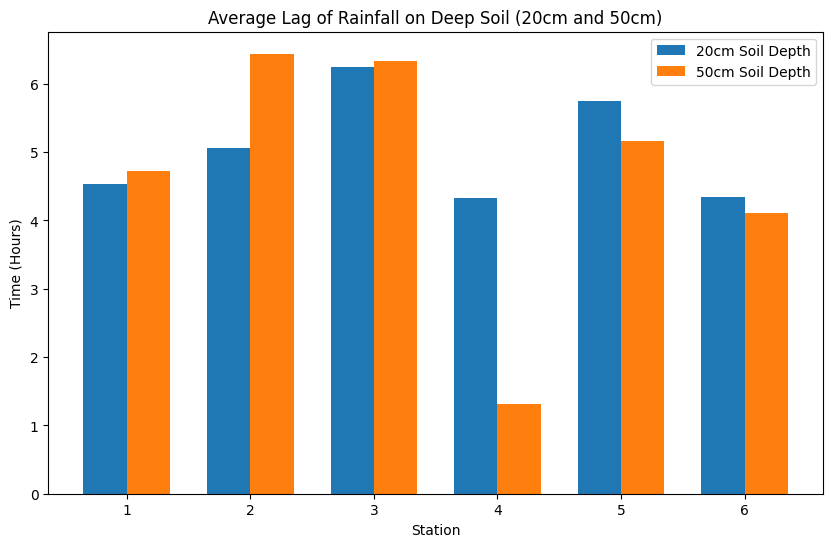

In [85]:
# Visualize data in bar plot
data = pd.DataFrame(station_data)

plt.figure(figsize=(10,6))
width = 0.35

plt.bar(data['station_id'] - width/2, data['avg_lag_20'], width, label = "20cm Soil Depth")
plt.bar(data['station_id'] + width/2, data['avg_lag_50'], width, label = "50cm Soil Depth")
plt.title("Average Lag of Rainfall on Deep Soil (20cm and 50cm)")
plt.xlabel("Station")
plt.ylabel('Time (Hours)')
plt.legend()
plt.show()

Station 1 and 6 have the shortest time for water to penetrate to the deeper soil levels. This may indicate easier water drainage/sand soil type

Station 2 and 3 have the longest time for water penetration to deeper soil levels. This can indicate clay soil types. i.e. water is retained at higher levels and takes longer to reach deeper soil levels.

In [86]:
data # Station lag data

,station_id,total_rainfall,avg_rainfall,avg_lag_20,avg_lag_50
0,1,3584.843044,12.578397,4.526316,4.726316
1,2,4001.670000,11.599043,5.060870,6.440580
2,3,4446.750000,13.156065,6.248521,6.337278
3,4,4087.750000,12.202239,4.325373,1.313433
4,5,3912.850000,11.022113,5.743662,5.169014
5,6,3718.830000,11.881246,4.345048,4.108626


## Do the soil stations experience a 2% change in SWC within an hour?

In [87]:
def swc_percentage_change(df, hour = 1):
    results = []

    event_starts = df[df['event_id'] != -1].groupby('event_id').first().reset_index()

    for _, row in event_starts.iterrows():
        event_id = row['event_id']
        event_start_idx = df[df['event_id'] == event_id].index[0]
        after_idx = event_start_idx + 1

        if after_idx >= len(df):
            continue  # skip if out of bounds

        baseline = df.loc[event_start_idx, 'SWC_10']
        after = df.loc[after_idx, 'SWC_10']

        percent_change = (after - baseline) / baseline if baseline != 0 else 0

        results.append({
            'event_id': event_id,
            'baseline': baseline,
            'after_1hr': after,
            'percent_change': percent_change
        })

    return pd.DataFrame(results)

Include more SWC depths**, maybe average percentage change is not the best stat?, take into account how long each rainfall event is?

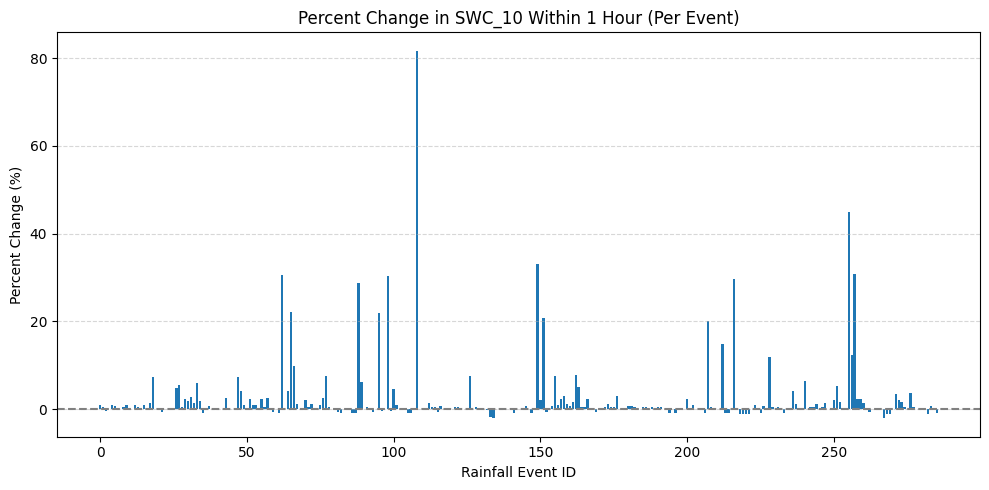

Average % Change in SWC_10, Station1: 2.1836482045913277


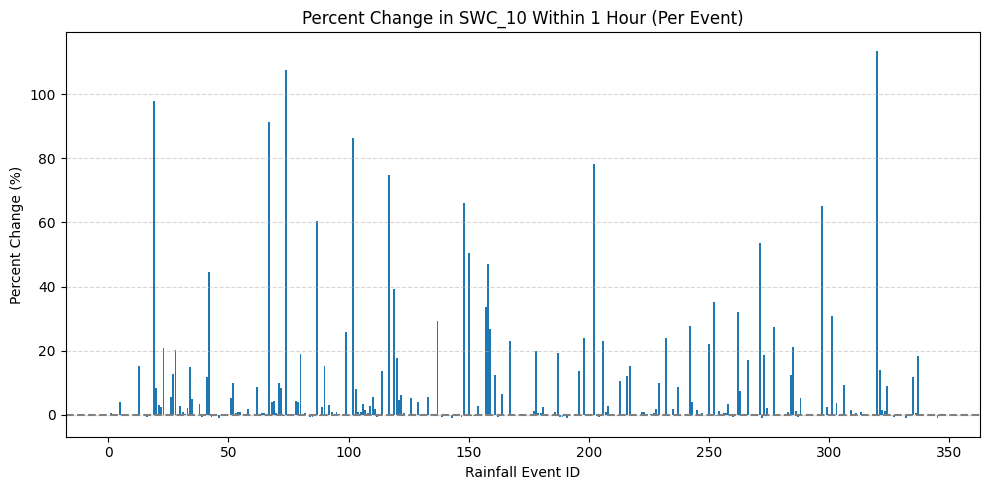

Average % Change in SWC_10, Station1: 6.0271575486282405


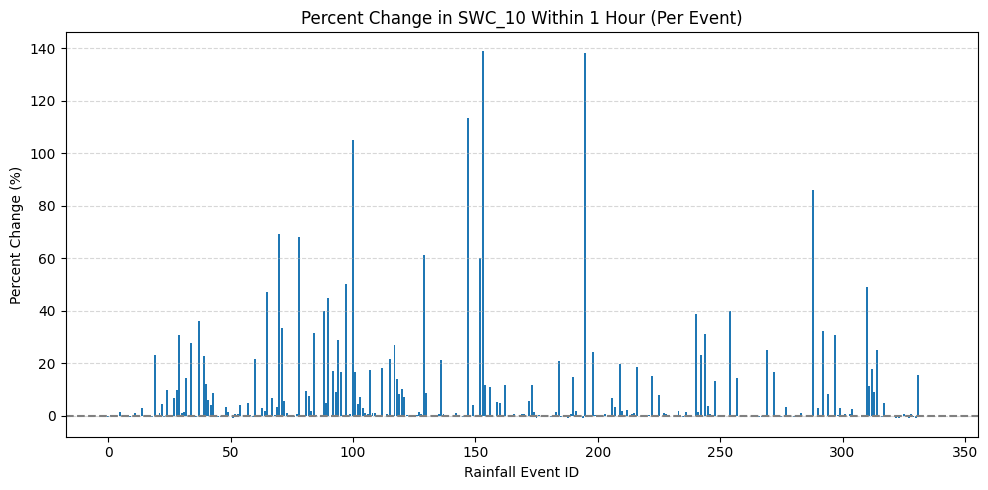

Average % Change in SWC_10, Station1: 6.767937167714861


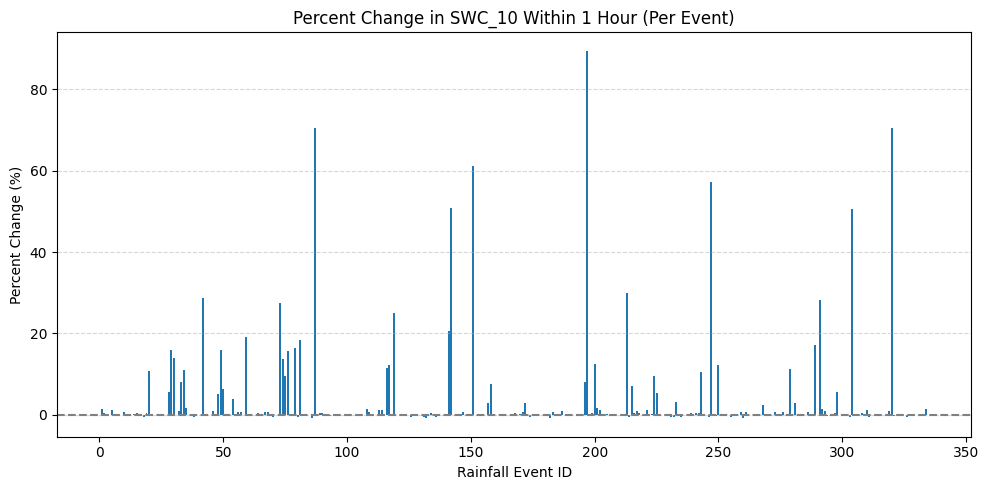

Average % Change in SWC_10, Station1: 2.9031448157208253


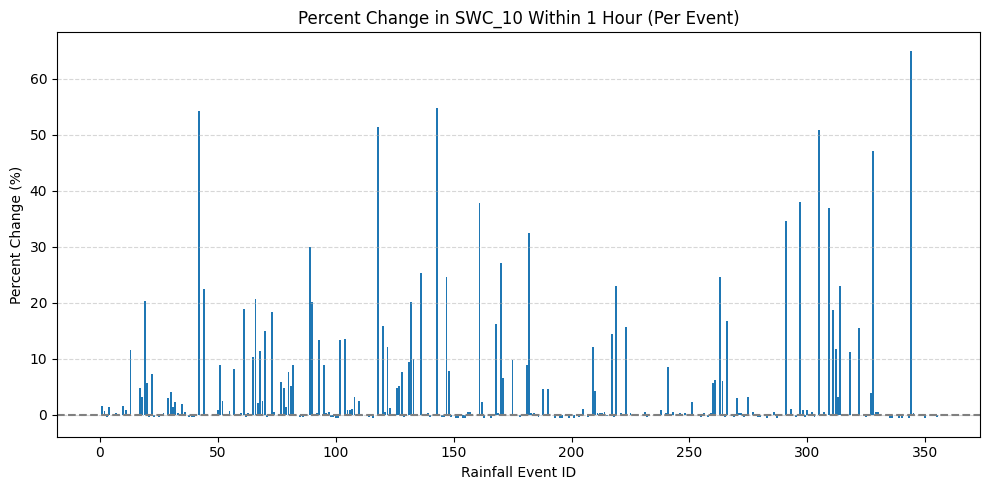

Average % Change in SWC_10, Station1: 3.696885901519652


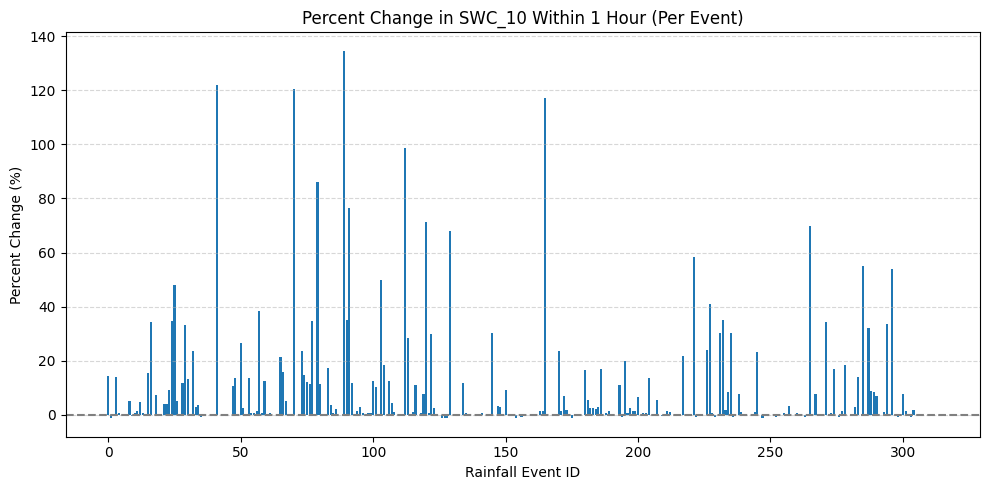

Average % Change in SWC_10, Station1: 8.242445844828275


In [99]:
for data in stations:
    i = 1
    summary_df = swc_percentage_change(data)
    
    plt.figure(figsize=(10, 5))
    plt.bar(summary_df['event_id'], summary_df['percent_change'] * 100)
    plt.axhline(0, color='gray', linestyle='--')
    plt.title("Percent Change in SWC_10 Within 1 Hour (Per Event)")
    plt.xlabel("Rainfall Event ID")
    plt.ylabel("Percent Change (%)")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print(f"Average % Change in SWC_10, Station{i}:", (sum(summary_df['percent_change']) / max(summary_df['event_id'])) * 100)
    i += 1

    

2.1836482045913277

In [ ]:
##